## 1. Setup

In [1]:
import sys, json, random, unicodedata
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score
)
import joblib

ROOT = Path().resolve().parent  # AdmissionChatbot/
sys.path.insert(0, str(ROOT / 'src'))
print('ROOT:', ROOT)

ROOT: E:\gitProjects\IntentClassiferOU


## 2. Load Dataset

In [2]:
DATA_FILE = ROOT / 'data' / 'intents' / 'intents.json'

with open(DATA_FILE, encoding='utf-8') as f:
    data = json.load(f)

texts_raw, labels_raw = [], []
for intent in data['intents']:
    for ex in intent['examples']:
        texts_raw.append(ex)
        labels_raw.append(intent['tag'])

print(f'Total samples  : {len(texts_raw)}')
print(f'Total intents  : {len(set(labels_raw))}')
print(f'\nIntent classes : {sorted(set(labels_raw))}')

Total samples  : 1077
Total intents  : 21

Intent classes : ['Chao_Hoi', 'Chung_Chi_Ngoai_Ngu', 'Co_Hoi_Viec_Lam', 'Co_So_Vat_Chat_Di_Lai', 'Diem_Chuan', 'He_Dao_Tao', 'Ho_So_Va_Nhap_Hoc', 'Hoat_Dong_Sinh_Vien', 'Hoc_Bong_Va_Ho_Tro', 'Hoc_Phi_Va_Thanh_Toan', 'Lien_Thong_Bang2', 'Phuong_Thuc_Xet_Tuyen', 'Quy_Che_Dao_Tao', 'So_Sanh', 'Thoi_Gian_Han_Chot', 'Thong_Tin_Dao_Tao', 'Thong_Tin_Nganh', 'To_Hop_Mon', 'Truot_Va_Diem_Liet', 'Tu_Van_Chon_Nganh', 'out_of_scope']


### Intent distribution

C:\Users\Dat\AppData\Local\Temp\ipykernel_62316\205638446.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.keys(), rotation=45, ha='right', fontsize=9)


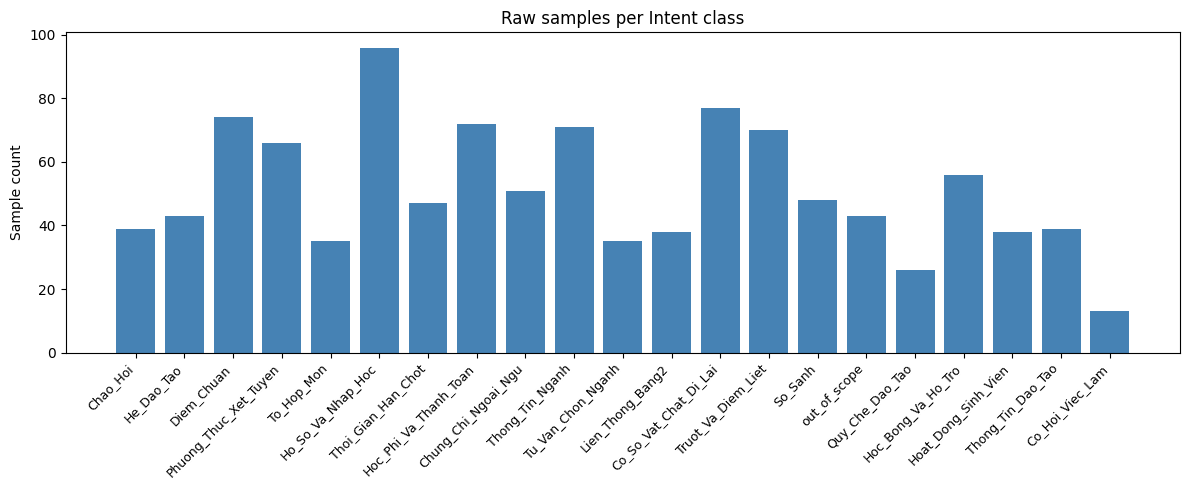

In [3]:
from collections import Counter
counts = Counter(labels_raw)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(counts.keys(), counts.values(), color='steelblue')
ax.set_xticklabels(counts.keys(), rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Sample count')
ax.set_title('Raw samples per Intent class')
plt.tight_layout()
plt.show()

## 3. Data Augmentation

In [4]:
def strip_diacritics(text: str) -> str:
    """Convert accented Vietnamese -> no-accent. E.g. 'điểm chuẩn' -> 'diem chuan'."""
    nfd = unicodedata.normalize('NFD', text)
    result = ''.join(c for c in nfd if unicodedata.category(c) != 'Mn'
                     and c not in ('\u0111', '\u0110'))
    return result.replace('đ', 'd').replace('Đ', 'D')


_TYPO_MAP = [
    ('ph', 'f'), ('ng', 'n'), ('nh', 'n'), ('ch', 'c'),
    ('kh', 'k'), ('gi', 'g'), ('qu', 'q'), ('tr', 't'), ('th', 't'),
]

def simulate_typo(text: str, p: float = 0.25) -> str:
    if random.random() > p:
        return text
    candidates = [(o, n) for o, n in _TYPO_MAP if o in text.lower()]
    if not candidates:
        return text
    old, new = random.choice(candidates)
    return text.lower().replace(old, new, 1)


def augment_data(texts, labels, seed=42):
    random.seed(seed)
    aug_t, aug_l = list(texts), list(labels)
    for text, label in zip(texts, labels):
        if label == 'out_of_scope':
            continue
        stripped = strip_diacritics(text)
        if stripped != text:
            aug_t.append(stripped); aug_l.append(label)
        typo_ver = simulate_typo(text, p=0.25)
        if typo_ver != text.lower():
            aug_t.append(typo_ver); aug_l.append(label)
    return aug_t, aug_l


texts_aug, labels_aug = augment_data(texts_raw, labels_raw)
print(f'Original : {len(texts_raw)} samples')
print(f'Augmented: {len(texts_aug)} samples (+{len(texts_aug)-len(texts_raw)} added)')

Original : 1077 samples
Augmented: 2889 samples (+1812 added)


## 4. NLP Preprocessing

In [5]:
from nlp.preprocessor import VietnamesePreprocessor

preprocessor = VietnamesePreprocessor()

# Demo
demo = [
    'Điểm chuẩn ngành CNTT năm nay bao nhiêu?',
    'diem chuan nganh cntt nam nay bao nhieu',
    'Học phí hệ CLC có đắt không?',
]
for s in demo:
    print(f'  IN : {s}')
    print(f'  OUT: {preprocessor.process(s)}')
    print()

# Preprocess full augmented set
texts_proc = preprocessor.process_batch(texts_aug)
labels_proc = labels_aug
print(f'Preprocessed {len(texts_proc)} samples.')

  IN : Điểm chuẩn ngành CNTT năm nay bao nhiêu?
  OUT: điểm chuẩn ngành cntt năm nay bao_nhiêu điem chuan nganh cntt nam nay bao

  IN : diem chuan nganh cntt nam nay bao nhieu
  OUT: diem chuan nganh cntt nam nay bao

  IN : Học phí hệ CLC có đắt không?
  OUT: học_phí hệ clc có đắt không hoc phi_he clc co_đat khong

Preprocessed 2889 samples.


## 5. Build Model Pipeline (Complement Naive Bayes)

In [6]:
def build_pipeline() -> Pipeline:
    """
    TF-IDF (1-2 gram) + Complement Naive Bayes.
    
    Bayesian inference:  P(c | x) ∝ P(c) × ∏ P(x_i | c)
    - P(c)       = class prior (uniform)
    - P(x_i | c) = TF-IDF weighted term likelihood
    - alpha=0.1  = Laplace smoothing to avoid zero-probability
    """
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.95,
            max_features=8000,
            sublinear_tf=True,
        )),
        ('clf', ComplementNB(alpha=0.1)),
    ])

pipeline = build_pipeline()
print(pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=8000,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('clf', ComplementNB(alpha=0.1))])


## 6. Cross-Validation (5-Fold)

5-Fold CV F1-Macro per fold:
  Fold 1: 0.8980
  Fold 2: 0.9072
  Fold 3: 0.8974
  Fold 4: 0.9092
  Fold 5: 0.8490
  Mean  : 0.8922 ± 0.0221


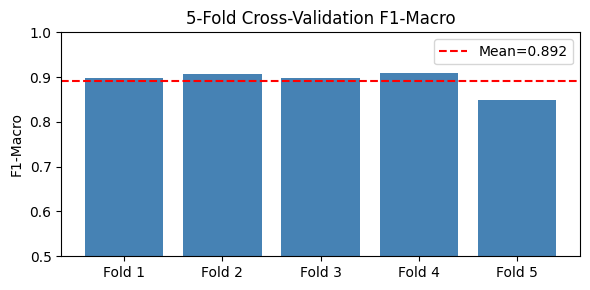

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(pipeline, texts_proc, labels_proc, cv=cv, scoring='f1_macro')

print('5-Fold CV F1-Macro per fold:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar([f'Fold {i}' for i in range(1, 6)], cv_scores, color='steelblue')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.3f}')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('F1-Macro')
ax.set_title('5-Fold Cross-Validation F1-Macro')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Per-Class Metrics (CV Predictions)

In [8]:
y_cv_pred = cross_val_predict(build_pipeline(), texts_proc, labels_proc, cv=cv)

acc  = accuracy_score(labels_proc, y_cv_pred)
f1   = f1_score(labels_proc, y_cv_pred, average='macro')
prec = precision_score(labels_proc, y_cv_pred, average='macro', zero_division=0)
rec  = recall_score(labels_proc, y_cv_pred, average='macro', zero_division=0)

print(f'Accuracy  (CV): {acc:.4f}')
print(f'F1-Macro  (CV): {f1:.4f}')
print(f'Precision (CV): {prec:.4f}')
print(f'Recall    (CV): {rec:.4f}')

print('\n--- Per-class classification report ---')
print(classification_report(labels_proc, y_cv_pred, zero_division=0))

Accuracy  (CV): 0.9211
F1-Macro  (CV): 0.8944
Precision (CV): 0.9385
Recall    (CV): 0.8831

--- Per-class classification report ---
                       precision    recall  f1-score   support

             Chao_Hoi       0.95      0.87      0.91       112
  Chung_Chi_Ngoai_Ngu       0.92      0.95      0.94       139
      Co_Hoi_Viec_Lam       1.00      0.73      0.84        33
Co_So_Vat_Chat_Di_Lai       0.92      0.98      0.95       204
           Diem_Chuan       0.91      0.96      0.93       207
           He_Dao_Tao       0.96      0.93      0.94       118
    Ho_So_Va_Nhap_Hoc       0.86      0.97      0.91       249
  Hoat_Dong_Sinh_Vien       0.96      0.98      0.97       103
   Hoc_Bong_Va_Ho_Tro       0.90      0.92      0.91       144
Hoc_Phi_Va_Thanh_Toan       0.94      0.93      0.93       202
     Lien_Thong_Bang2       0.95      0.87      0.91       113
Phuong_Thuc_Xet_Tuyen       0.88      0.88      0.88       179
      Quy_Che_Dao_Tao       1.00      0.87     

## 8. Confusion Matrix

Saved -> E:\gitProjects\IntentClassiferOU\models\confusion_matrix.png


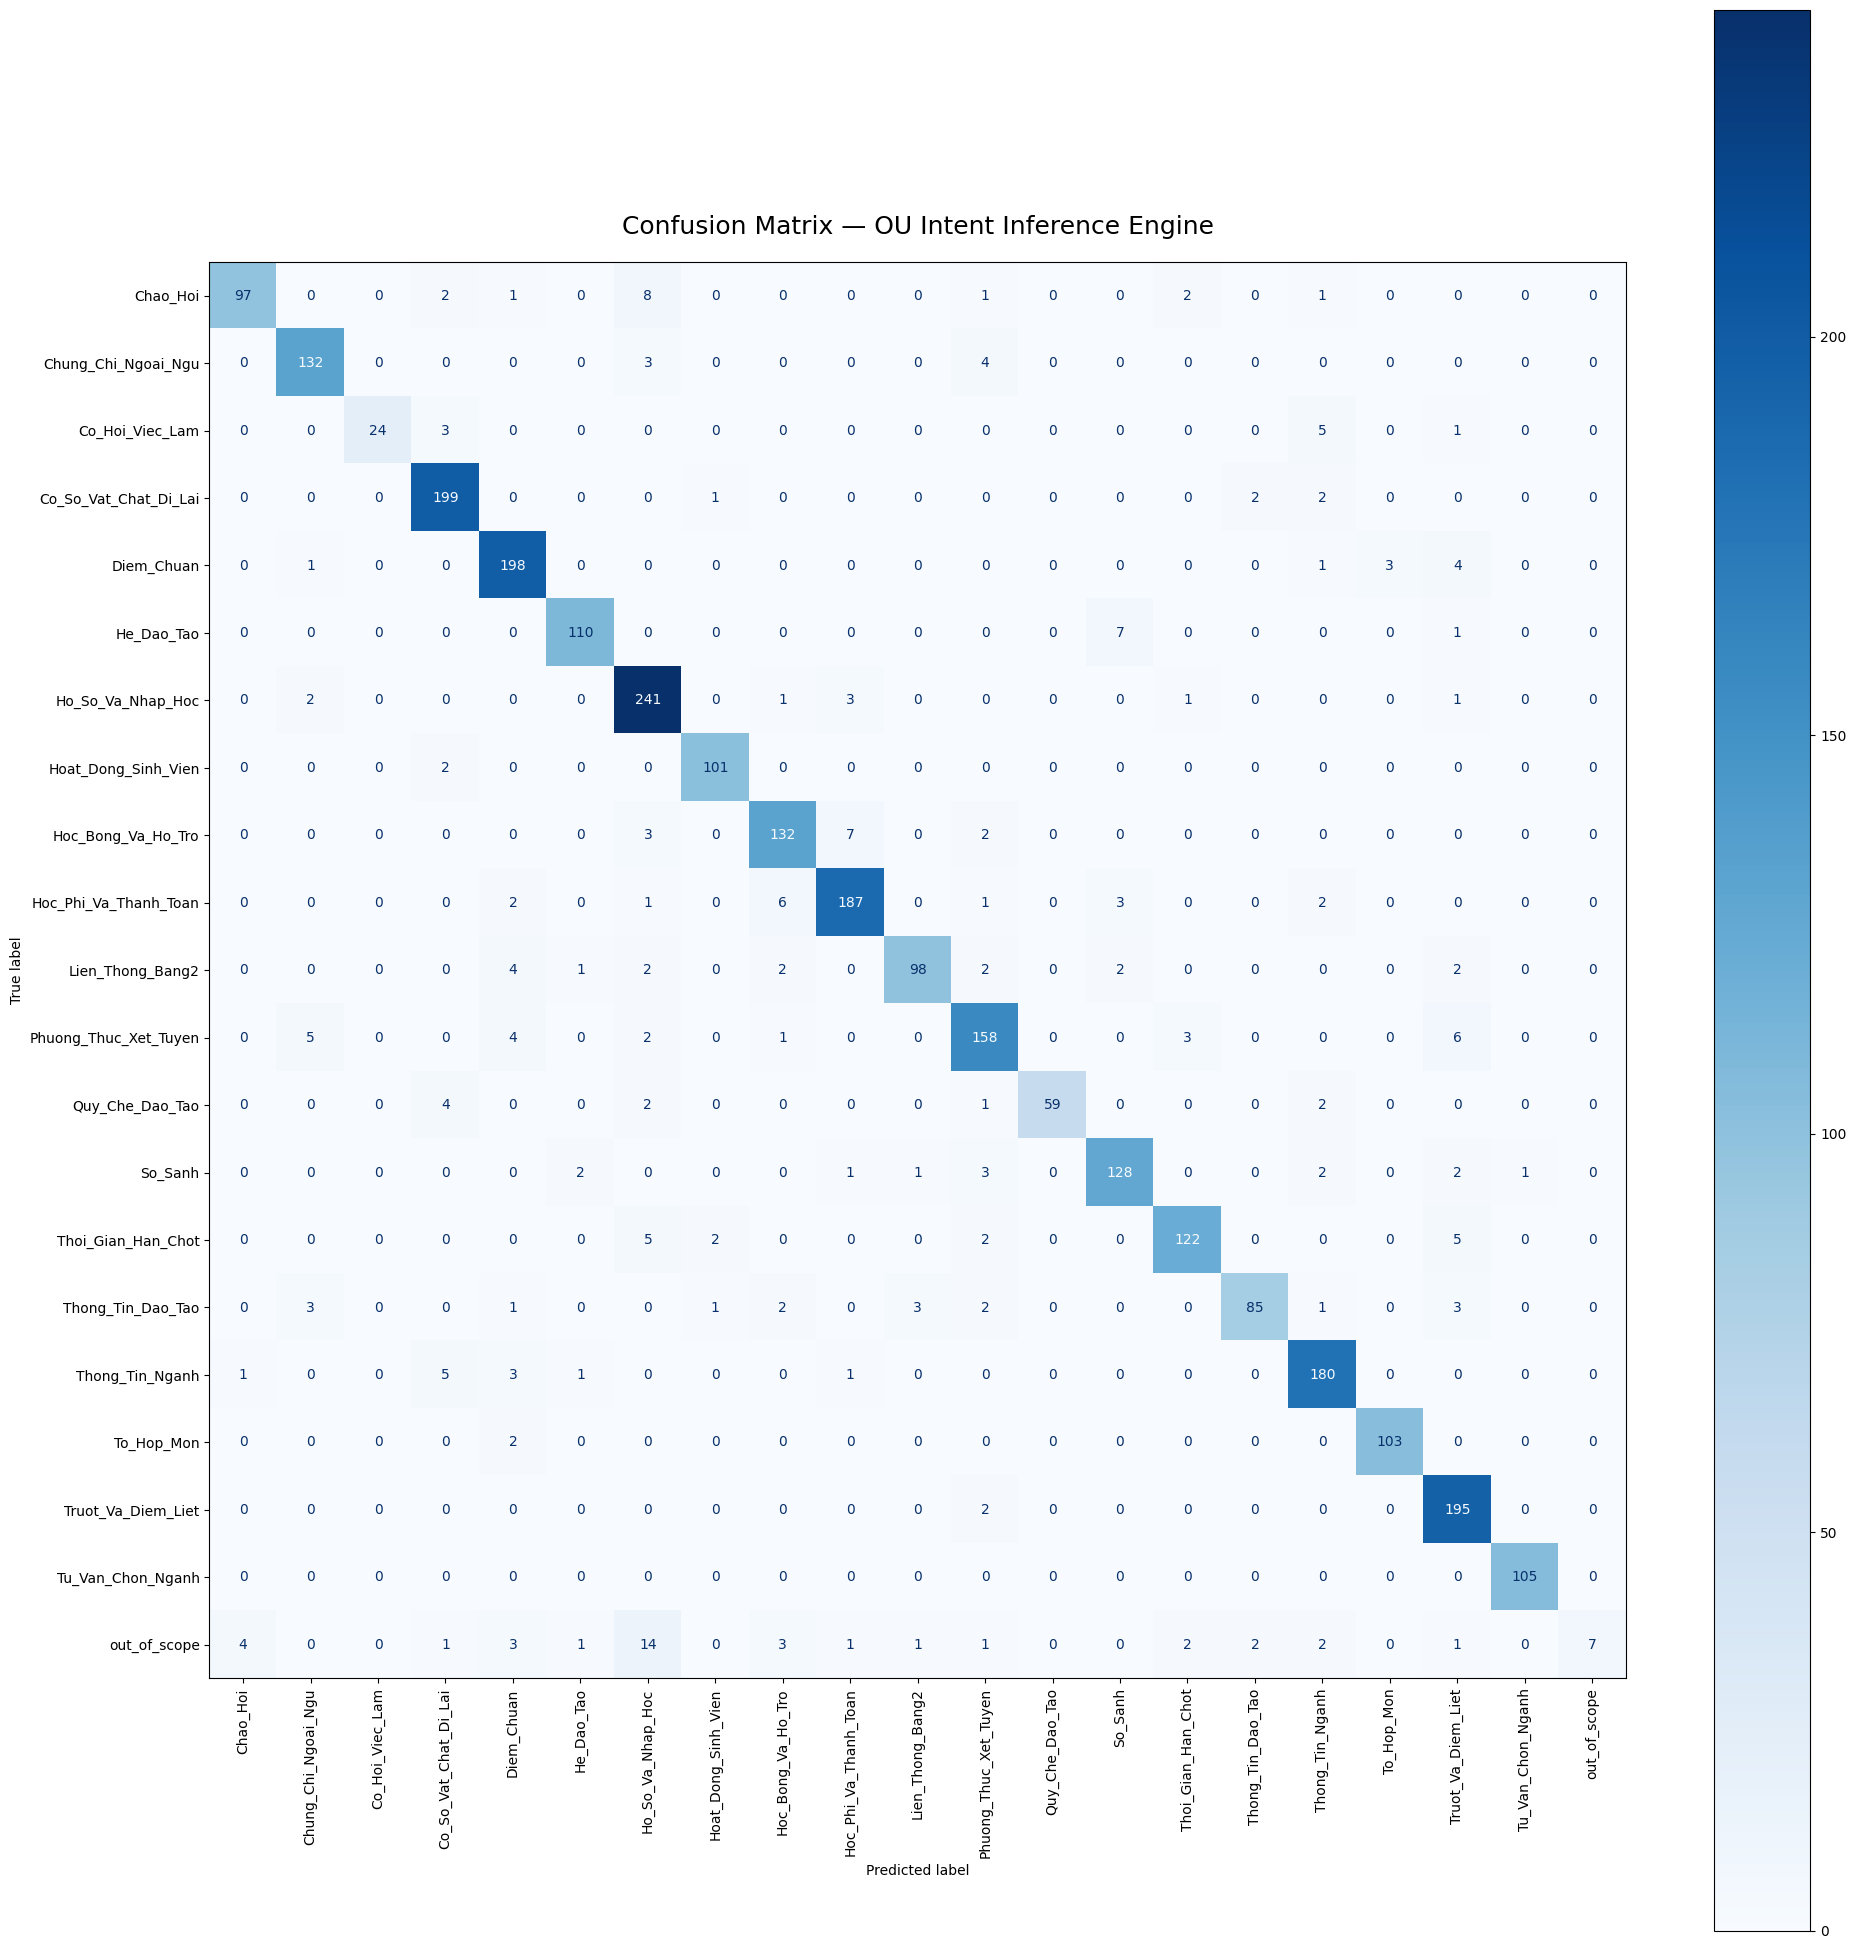

In [9]:
unique_labels = sorted(set(labels_proc))
cm = confusion_matrix(labels_proc, y_cv_pred, labels=unique_labels)

fig, ax = plt.subplots(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_labels)
disp.plot(include_values=True, cmap='Blues', ax=ax,
          xticks_rotation='vertical', values_format='d')
ax.set_title('Confusion Matrix — OU Intent Inference Engine', fontsize=18, pad=20)
plt.tight_layout()

CM_PATH = ROOT / 'models' / 'confusion_matrix.png'
plt.savefig(CM_PATH, dpi=300, bbox_inches='tight')
print(f'Saved -> {CM_PATH}')
plt.show()

## 9. Train on Full Dataset & Export Model

In [10]:
pipeline = build_pipeline()
pipeline.fit(texts_proc, labels_proc)

MODEL_DIR = ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / 'intent_classifier.pkl'
LABELS_PATH = MODEL_DIR / 'labels.json'

joblib.dump(pipeline, MODEL_PATH)
with open(LABELS_PATH, 'w', encoding='utf-8') as f:
    json.dump(unique_labels, f, ensure_ascii=False, indent=2)

print(f'Model  saved -> {MODEL_PATH}')
print(f'Labels saved -> {LABELS_PATH}')

Model  saved -> E:\gitProjects\IntentClassiferOU\models\intent_classifier.pkl
Labels saved -> E:\gitProjects\IntentClassiferOU\models\labels.json


## 10. Load Model & Run Inference

In [11]:
loaded_pipeline = joblib.load(MODEL_PATH)
with open(LABELS_PATH, encoding='utf-8') as f:
    loaded_labels = json.load(f)

print(f'Loaded model with {len(loaded_labels)} intent classes.\n')

test_queries = [
    'Điểm chuẩn ngành CNTT năm nay bao nhiêu?',
    'Học phí mỗi kỳ hết bao nhiêu tiền?',
    'Trường có ký túc xá không?',
    'Có IELTS 6.0 thì được cộng điểm không?',
    'Hồ sơ nhập học cần những gì?',
    'Ngành CNTT ra trường làm gì?',
    'Chào bạn, mình muốn hỏi về tuyển sinh',
    'CLC khác đại trà như thế nào?',
]

print(f'{"Query":<55} {"Intent":<30} {"Confidence":>12}')
print('-' * 100)
for q in test_queries:
    proba  = loaded_pipeline.predict_proba([q])[0]
    intent = loaded_pipeline.classes_[np.argmax(proba)]
    conf   = np.max(proba)
    print(f'{q[:54]:<55} {intent:<30} {conf:>11.2%}')

Loaded model with 21 intent classes.

Query                                                   Intent                           Confidence
----------------------------------------------------------------------------------------------------
Điểm chuẩn ngành CNTT năm nay bao nhiêu?                Diem_Chuan                          99.38%
Học phí mỗi kỳ hết bao nhiêu tiền?                      Hoc_Phi_Va_Thanh_Toan               97.04%
Trường có ký túc xá không?                              Co_So_Vat_Chat_Di_Lai               63.26%
Có IELTS 6.0 thì được cộng điểm không?                  Chung_Chi_Ngoai_Ngu                 98.52%
Hồ sơ nhập học cần những gì?                            Ho_So_Va_Nhap_Hoc                   48.98%
Ngành CNTT ra trường làm gì?                            Thong_Tin_Nganh                     94.60%
Chào bạn, mình muốn hỏi về tuyển sinh                   Chao_Hoi                            99.24%
CLC khác đại trà như thế nào?                           So_Sanh     

## 11. Full Probability Distribution (Single Query)

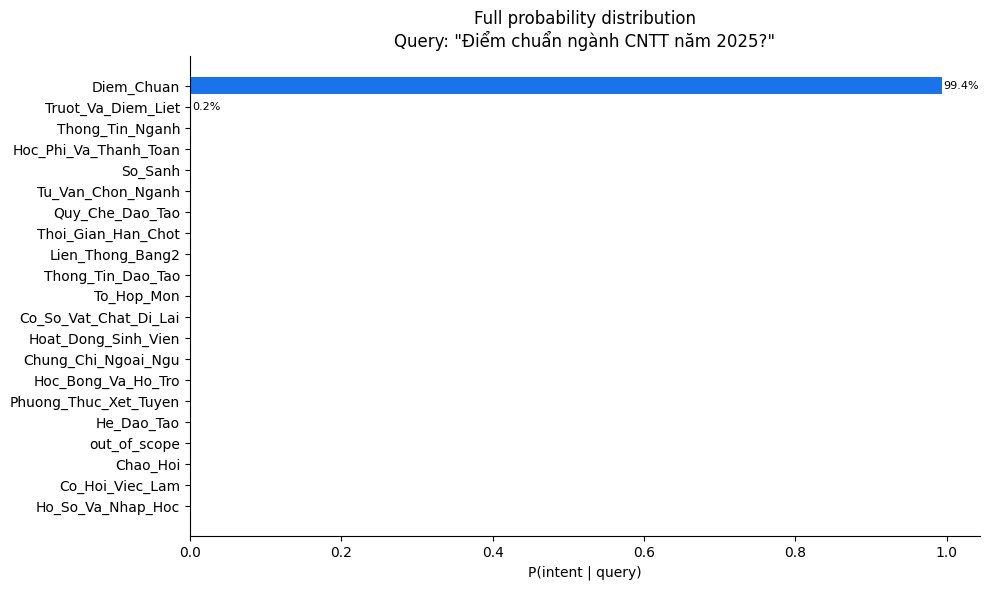

In [12]:
query = 'Điểm chuẩn ngành CNTT năm 2025?'
proba = loaded_pipeline.predict_proba([query])[0]
classes = loaded_pipeline.classes_

# Sort descending
sorted_idx = np.argsort(proba)[::-1]
sorted_classes = classes[sorted_idx]
sorted_proba   = proba[sorted_idx]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1a73e8' if c == sorted_classes[0] else '#dadce0' for c in sorted_classes]
ax.barh(sorted_classes[::-1], sorted_proba[::-1], color=colors[::-1])
ax.set_xlabel('P(intent | query)')
ax.set_title(f'Full probability distribution\nQuery: "{query}"')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, (p, c) in enumerate(zip(sorted_proba[::-1], sorted_classes[::-1])):
    if p > 0.001:
        ax.text(p + 0.001, i, f'{p:.1%}', va='center', fontsize=8)
plt.tight_layout()
plt.show()